# BILSTM + BiDAF on SQUADv2.0 dataset

## 0) Imports


Libraries and PyTorch modules used throughout the notebook.

In [8]:
import os, re, json, collections
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import math, os


## 1) Global configurations and loading of the dataset

### 1.1) Global configurations


All hyperparameters and file paths are centralised here — change a value once and every subsequent cell picks it up automatically.

**Embeddings**
- `EMBED_DIM = 300`: GloVe 6B.300d word vectors

- `CHAR_EMBED_DIM = 64`: character embedding dimension

- `CHAR_OUT_DIM = 100`: CNN filters per token (BiDAF paper value)

- `CHAR_KERNEL = 5`: CNN filter width in characters

- `MAX_WORD_LEN = 16`: tokens longer than this are truncated before the char CNN

Each token's final input vector is: **GloVe (300) + CharCNN (100) + ExactMatch (1) = 401 dims**, projected back to 300 via the highway network.

**Sequence caps**
- `MAX_CONTEXT = 300` tokens — longer passages are re-centred around the answer span

- `MAX_QUESTION = 40` tokens — questions are rarely longer

**Special tokens:** `<PAD>` (index 0, all-zeros embedding) and `<UNK>` (unknown words).

**Paths:** training, validation, and test JSON files + GloVe vectors. Device is set to CUDA if available.


#### Why re-centering and not doc_stride?

BiDAF operates on a fixed word-level vocabulary (GloVe) and has no native mechanism to map token positions back to character offsets in the original text. Implementing `doc_stride` would require splitting the context into overlapping chunks, running the model on each chunk independently, and then reconciling potentially conflicting span predictions across chunks — logic that is non-trivial to implement correctly and is not part of the original BiDAF architecture (Seo et al. 2016).

Re-centering is the architecturally coherent alternative: when a context exceeds `MAX_CONTEXT = 300` tokens, a window of 300 tokens is extracted and centred around the answer span midpoint, ensuring the answer is always inside the window. For unanswerable questions the first 300 tokens are used. Examples where the answer cannot fit in any window are demoted to unanswerable to avoid training on an incorrect label.

This contrasts with the DeBERTa pipeline used in the other model, where `doc_stride` is trivially supported because the HuggingFace tokenizer natively provides `offset_mapping` — a character-level alignment between every subword token and the original string. This makes it straightforward to split, overlap, and reconcile chunks. Without `offset_mapping`, as in GloVe-based models, the same reconciliation would have to be implemented manually from scratch.

In short: **doc_stride requires offset_mapping; GloVe does not provide it; re-centering is the correct solution for BiDAF.**

### 1.2) Loading of the dataset and flattening

SQuAD 2.0 is a nested JSON (`data → articles → paragraphs → qas`). `flatten_squad` converts it into a flat DataFrame where each row is one (context, question, answer) triple — the atomic training unit.

Each row has **8 columns:** `id`, `title`, `paragraph_id`, `context`, `question`, `can_answer`, `answer_text`, `answer_start`.

- Answerable questions: `can_answer = 'yes'`, answer text and character offset from the first annotator

- Unanswerable questions: `can_answer = 'no'`, `answer_text = 'NO_ANSWER'`, `answer_start = -1`

~50% of SQuAD 2.0 questions are unanswerable by design.

In [9]:
## GLOBAL CONFIGURATIONS
EMBED_DIM = 300    # must match the GloVe file used (6B.300d → 300 dimensions)


CHAR_EMBED_DIM = 64   # Each individual character (e.g. 'a', 'B', '3') is first

CHAR_OUT_DIM   = 100  # The 1-D CNN applies 100 filters over the character sequence

CHAR_KERNEL    = 5    # Each CNN filter looks at a window of 5 consecutive characters

MAX_WORD_LEN   = 16   # Tokens longer than 16 characters are truncated before


MAX_CONTEXT  = 300   # maximum number of tokens in the passage
MAX_QUESTION = 40    # maximum number of tokens in the question

PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'


TRAIN_PATH = "/workspace/v2/train_sampled.json"                 # training set   (~70k examples)
VAL_PATH   = "/workspace/v2/val_sampled.json"                   #validation set (~9k  examples)
TEST_PATH  = "/workspace/v2/test_sampled.json"                   # test set       (~9k  examples)

GLOVE_PATH = "/workspace/newmodel/glove.6B.300d.txt"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


## LOADING OF THE DATASET AND FLATTENING
def flatten_squad(path: str) -> pd.DataFrame:
    """
    Converts the nested SQuAD 2.0 JSON structure into a flat DataFrame.

    Each row represents one question and contains 8 columns:
      - id           : unique question identifier (string)
      - title        : Wikipedia article title (string)
      - paragraph_id : unique paragraph identifier, format 'title__index' (string)
      - context      : the passage of text the question refers to (string)
      - question     : the question text (string)
      - can_answer   : 'yes' if the question has an answer in the passage, 'no' otherwise
      - answer_text  : the answer string extracted from the passage;
                       'NO_ANSWER' for unanswerable questions
      - answer_start : character offset of the answer in the context string;
                       -1 for unanswerable questions

    SQuAD 2.0 note: approximately 50% of questions are marked is_impossible=True,
    meaning no span in the passage answers the question. The model must learn
    to output an empty answer for these cases rather than hallucinating a span.

    Args:
        path: absolute path to the SQuAD 2.0 JSON file.

    Returns:
        A pandas DataFrame with one row per question-answer pair.
    """
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows = []

    for article in data['data']:
        title = article['title']
        for para_i, para in enumerate(article['paragraphs']):
            context      = para['context']
            paragraph_id = f"{title}__{para_i}"

            for qa in para['qas']:
                is_impossible = qa.get('is_impossible', False)
                can_answer    = 'yes' if not is_impossible else 'no'

                if can_answer == 'yes' and len(qa.get('answers', [])) > 0:
                    answer_text  = qa['answers'][0]['text']
                    answer_start = qa['answers'][0]['answer_start']
                else:
                    answer_text  = 'NO_ANSWER'
                    answer_start = -1

                rows.append({
                    'id':           qa['id'],
                    'title':        title,
                    'paragraph_id': paragraph_id,
                    'context':      context,
                    'question':     qa['question'],
                    'can_answer':   can_answer,
                    'answer_text':  answer_text,
                    'answer_start': answer_start
                })

    return pd.DataFrame(rows)


train_df = flatten_squad(TRAIN_PATH)
val_df   = flatten_squad(VAL_PATH)
test_df  = flatten_squad(TEST_PATH)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'Answerable train: {(train_df["can_answer"] == "yes").mean():.2%}')

Device: cuda
Train: 70807 | Val: 8913 | Test: 8990
Answerable train: 57.39%


## 2) Text Processing Pipeline: Tokenisation, Span Alignment & Preprocessing



This section prepares raw text for the model in three stages:

### 2.1) Tokenisation, Vocabularies & GloVe Embeddings


Builds the three data structures all downstream cells depend on:

- **`word2idx`**: word → integer index (capped at 50k, built from all three splits to avoid OOV)

- **`char2idx`**: character → integer index (~80–100 unique chars, uncapped)

- **`glove_emb`**: numpy matrix `(vocab_size × 300)`: GloVe vectors where available, random `Uniform(−0.1, 0.1)` for OOV, all-zeros for `<PAD>`

Tokenisation: lowercase + spaces around punctuation → split on whitespace. Compatible with the GloVe vocabulary convention.

In [10]:
def tokenize(text: str) -> List[str]:
    text = str(text).lower()
    text = re.sub(r"([.,!?;:\"'()\[\]{}])", r" \1 ", text)
    return text.split()


def build_vocab(dfs: List[pd.DataFrame], max_vocab: int = 50000) -> Dict[str, int]:
    counter = collections.Counter()
    for df in dfs:
        for text in df['context'].tolist() + df['question'].tolist():
            counter.update(tokenize(text))

    vocab  = [PAD_TOKEN, UNK_TOKEN]
    vocab += [w for w, _ in counter.most_common(max_vocab - 2)]

    return {w: i for i, w in enumerate(vocab)}


def build_char_vocab(dfs: List[pd.DataFrame]) -> Dict[str, int]:
    char_set = set()
    for df in dfs:
        for text in df['context'].tolist() + df['question'].tolist():
            char_set.update(str(text).lower())

    char_list = ['<PAD_C>', '<UNK_C>'] + sorted(char_set)
    return {c: i for i, c in enumerate(char_list)}


def load_glove(glove_path: str, word2idx: Dict[str, int],
               embed_dim: int = 300) -> np.ndarray:
    """
    Loads pre-trained GloVe word vectors and aligns them with word2idx.

    GloVe (Pennington et al., 2014) provides pre-trained dense vector
    representations for nearly 400k English words. Each vector encodes semantic
    and syntactic similarity: words used in similar contexts have vectors
    that are geometrically close. Using pre-trained GloVe vectors instead
    of random initialisation gives the model a strong starting point and
    significantly reduces the amount of training data needed.

    Initialisation strategy:
      - Words found in GloVe     → use the pre-trained vector directly.
      - Words NOT found in GloVe → initialise with a small random vector
                                   drawn from Uniform(-0.1, 0.1). This is
                                   preferable to all-zeros because it breaks
                                   symmetry and allows the embedding to be
                                   fine-tuned during training.
      - PAD token               → fixed at all-zeros. Since padding positions
                                   are masked in attention and pooling, their
                                   embedding value should not influence the output.

    Args:
        glove_path: path to the GloVe text file (one word + 300 floats per line).
        word2idx:   the vocabulary dict built by build_vocab().
        embed_dim:  dimensionality of the GloVe vectors (must match the file).

    Returns:
        embeddings: numpy array of shape (vocab_size, embed_dim), dtype float32.
    """
    print('Loading GloVe embeddings...')

    embeddings = np.random.uniform(-0.1, 0.1,
                                   (len(word2idx), embed_dim)).astype(np.float32)
    embeddings[word2idx[PAD_TOKEN]] = 0.0

    found = 0
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(' ')
            word  = parts[0]
            if word in word2idx:
                embeddings[word2idx[word]] = np.array(parts[1:], dtype=np.float32)
                found += 1

    print(f'GloVe: {found}/{len(word2idx)} words found ({found/len(word2idx):.1%})')
    return embeddings


word2idx  = build_vocab([train_df, val_df, test_df])
char2idx  = build_char_vocab([train_df, val_df, test_df])
glove_emb = load_glove(GLOVE_PATH, word2idx)

print(f'Word vocab size: {len(word2idx)}')
print(f'Char vocab size: {len(char2idx)}')   # includes all unicode chars found in the dataset (contexts + questions)

Loading GloVe embeddings...
GloVe: 42965/50000 words found (85.9%)
Word vocab size: 50000
Char vocab size: 1202


### 2.2) Character-to-Token Span Alignment


SQuAD provides answer positions as **character offsets**, but the model predicts **token indices**. `find_token_span` converts between the two.

It builds an explicit `char → token` map by reconstructing the space-separated token string character by character. A **±10-character fuzzy fallback** handles small misalignments caused by the tokeniser inserting extra spaces around punctuation.

Returns `(-1, -1)` if alignment fails — the example is then treated as unanswerable to avoid training on a wrong label.

In [11]:
def find_token_span(
    context_tokens:    List[str],
    answer_text:       str,
    answer_start_char: int
) -> Tuple[int, int]:
    """
    Args:
        context_tokens:    list of string tokens from tokenize(context).
        answer_text:       the gold answer string (e.g. "Warsaw").
        answer_start_char: character offset of the answer in the original
                           (pre-tokenisation) context string, as provided
                           by SQuAD.
    Returns:
        (start_tok, end_tok): zero-based token indices, inclusive on both ends.
                               Returns (-1, -1) if alignment fails — the example
                               will be marked as unanswerable.
    """
    if answer_start_char < 0 or not answer_text:
        return -1, -1

    char_to_token = {}
    current_char  = 0
    for i, token in enumerate(context_tokens):
        for ch in token:
            char_to_token[current_char] = i   # this character belongs to token i
            current_char += 1
        current_char += 1   # skip the space between tokens (not mapped)

    answer_end_char = answer_start_char + len(answer_text)
    start_tok = char_to_token.get(answer_start_char)
    end_tok   = char_to_token.get(answer_end_char - 1)

    if start_tok is None:
        for pos in range(answer_start_char, answer_start_char + 10):
            if pos in char_to_token:
                start_tok = char_to_token[pos]
                break

    if end_tok is None:
        for pos in range(answer_end_char - 1, answer_end_char - 10, -1):
            if pos in char_to_token:
                end_tok = char_to_token[pos]
                break

    if start_tok is None or end_tok is None or end_tok < start_tok:
        return -1, -1

    return start_tok, end_tok


### 2.3) Preprocessing: Word IDs, Char IDs, Exact-Match Feature


Converts raw text DataFrames into numerical tensors ready for the model. For each example:

1. **Tokenise** context and question via `tokenize()`

2. **Find answer span** (token indices) via `find_token_span()` — returns `(-1, -1)` if alignment fails

3. **Truncate context** to `MAX_CONTEXT=300` tokens: if the passage is longer, a window is re-centred around 
the answer span midpoint. If the answer cannot fit in any window, the example is demoted to unanswerable.

4. **Encode word IDs + attention masks** via `encode_sequence()` — unknown words → `<UNK>`, padding → `<PAD>` (index 0)

5. **Encode char IDs** via `tokens_to_char_ids()` — 2D matrix `(seq_len, MAX_WORD_LEN)` per sequence

6. **Exact-match feature** via `exact_match_feature()` — binary `1.0` if a context token appears in the question, `0.0` otherwise

7. **Clip span indices** to valid range; examples with failed alignment are demoted to unanswerable (`answerable=0`, span set to dummy `(0,0)`)

Tensors are stored on CPU; the training loop moves them to GPU batch by batch.

In [15]:
def tokens_to_char_ids(
    tokens:       List[str],
    char2idx:     Dict[str, int],
    max_seq_len:  int,
    max_word_len: int = MAX_WORD_LEN
) -> List[List[int]]:
    """
    Args:
        tokens:       list of string tokens (from tokenize()).
        char2idx:     character vocabulary dict from build_char_vocab().
        max_seq_len:  maximum sequence length (MAX_CONTEXT or MAX_QUESTION).
        max_word_len: maximum characters per token (MAX_WORD_LEN = 16).

    Returns:
        2-D list of shape (max_seq_len, max_word_len) containing int indices.

    Example (max_word_len=5):
        tokens = ['hi', 'there']
        → [[ h_idx, i_idx, 0, 0, 0 ],
           [ t_idx, h_idx, e_idx, r_idx, e_idx ],
           [ 0, 0, 0, 0, 0 ],  ← padding rows
          ]
    """
    unk_c = char2idx.get('<UNK_C>', 1)   # index for unknown characters
    pad_c = char2idx.get('<PAD_C>', 0)   # index for padding characters

    result = []
    for tok in tokens[:max_seq_len]:
        ids = [char2idx.get(c, unk_c) for c in tok[:max_word_len]]
        ids = ids + [pad_c] * (max_word_len - len(ids))
        result.append(ids)

    while len(result) < max_seq_len:
        result.append([pad_c] * max_word_len)

    return result   # shape: (max_seq_len, max_word_len)


def exact_match_feature(
    ctx_tokens: List[str],
    q_tokens:   List[str],
    max_c_len:  int
) -> List[float]:
    
    q_set = set(t.lower() for t in q_tokens)
    feats = [1.0 if t.lower() in q_set else 0.0
             for t in ctx_tokens[:max_c_len]]
    feats += [0.0] * (max_c_len - len(feats))
    return feats


def encode_sequence(
    tokens:   List[str],
    word2idx: Dict[str, int],
    max_len:  int
) -> Tuple[List[int], List[int]]:
    """
    Args:
        tokens:   list of string tokens (from tokenize()).
        word2idx: word vocabulary dict from build_vocab().
        max_len:  target sequence length (MAX_CONTEXT or MAX_QUESTION).

    Returns:
        ids:  list of int word indices, length max_len.
        mask: list of {0, 1} ints — 1=real token, 0=padding.

    Example (max_len=5):
        tokens = ['who', 'founded', 'apple']
        → ids  = [who_idx, founded_idx, apple_idx, 0, 0]
        → mask = [1,       1,           1,          0, 0]
    """
    unk     = word2idx[UNK_TOKEN]
    pad     = word2idx[PAD_TOKEN]
    ids     = [word2idx.get(t, unk) for t in tokens[:max_len]]
    pad_len = max_len - len(ids)
    mask    = [1] * len(ids) + [0] * pad_len   # 1=real, 0=padding
    ids     = ids + [pad] * pad_len             # right-pad with PAD index
    return ids, mask

def preprocess_df(
    df:        pd.DataFrame,
    word2idx:  Dict[str, int],
    char2idx:  Dict[str, int],
    max_q_len: int = MAX_QUESTION,
    max_c_len: int = MAX_CONTEXT
) -> Dict:
    """
    Converts a raw SQuAD DataFrame into a dict of PyTorch tensors ready
    for the DataLoader. Processes each example row by row:
      1. Tokenise context and question.
      2. Find the answer token span via find_token_span().
      3. Truncate context to max_c_len, re-centring around the answer midpoint.
      4. Encode word ids + attention masks for context and question.
      5. Encode character ids for context and question.
      6. Compute the exact-match feature for the context.
      7. Clip span indices and handle alignment failures.

    Args:
        df:        DataFrame from flatten_squad().
        word2idx:  word vocabulary from build_vocab().
        char2idx:  character vocabulary from build_char_vocab().
        max_q_len: maximum question length in tokens.
        max_c_len: maximum context length in tokens.

    Returns:
        Dictionary of tensors with keys:
          ctx_ids, ctx_masks, ctx_chars, ctx_em  — context features
          q_ids, q_masks, q_chars                — question features
          start, end, answerable                 — labels
          ctx_tokens, ids, gold_texts            — metadata (Python lists)
    """
    all_ctx_ids    = []
    all_ctx_masks  = []
    all_ctx_chars  = []   # character ids for context
    all_ctx_em     = []   # exact-match feature for context
    all_q_ids      = []
    all_q_masks    = []
    all_q_chars    = []   # character ids for question
    all_start      = []
    all_end        = []
    all_answerable = []
    all_ctx_tokens = []
    all_ids        = []
    all_gold_texts = []
    bad_spans      = 0    # counter for examples where span alignment failed

    for _, row in tqdm(df.iterrows(), total=len(df), desc='Preprocessing'):

        ctx_tokens = tokenize(row['context'])
        q_tokens   = tokenize(row['question'])
        answerable = int(row['can_answer'] == 'yes')

        if answerable and row['answer_start'] >= 0:
            start_tok, end_tok = find_token_span(
                ctx_tokens, str(row['answer_text']), int(row['answer_start'])
            )
        else:
            start_tok, end_tok = -1, -1

        if len(ctx_tokens) > max_c_len:
            if answerable and start_tok >= 0 and end_tok >= 0:
                center   = (start_tok + end_tok) // 2
                half_win = max_c_len // 2
                left     = max(0, center - half_win)
                right    = min(len(ctx_tokens), left + max_c_len)
                left     = max(0, right - max_c_len)  # adjust if near end
                if left <= start_tok and end_tok < right:
                    start_tok -= left
                    end_tok   -= left
                    ctx_tokens = ctx_tokens[left:right]
                else:
                    ctx_tokens = ctx_tokens[:max_c_len]
                    start_tok, end_tok = -1, -1
            else:
                ctx_tokens = ctx_tokens[:max_c_len]

        if answerable and (start_tok < 0 or end_tok < 0):
            bad_spans += 1
            answerable    = 0
            start_tok, end_tok = 0, 0   # dummy values, ignored by loss
        elif not answerable:
            start_tok, end_tok = 0, 0   # dummy values, ignored by loss

        start_tok = min(max(start_tok, 0), max_c_len - 1)
        end_tok   = min(max(end_tok, start_tok), max_c_len - 1)

        ctx_ids, ctx_mask = encode_sequence(ctx_tokens, word2idx, max_c_len)
        q_ids,   q_mask   = encode_sequence(q_tokens,   word2idx, max_q_len)

        ctx_chars = tokens_to_char_ids(ctx_tokens, char2idx, max_c_len)
        q_chars   = tokens_to_char_ids(q_tokens,   char2idx, max_q_len)

        ctx_em = exact_match_feature(ctx_tokens, q_tokens, max_c_len)

        all_ctx_ids.append(ctx_ids);     all_ctx_masks.append(ctx_mask)
        all_ctx_chars.append(ctx_chars); all_ctx_em.append(ctx_em)
        all_q_ids.append(q_ids);         all_q_masks.append(q_mask)
        all_q_chars.append(q_chars)
        all_start.append(start_tok);     all_end.append(end_tok)
        all_answerable.append(answerable)
        all_ctx_tokens.append(ctx_tokens)
        all_ids.append(row['id']);       all_gold_texts.append(row['answer_text'])

    print(f'Spans not found: {bad_spans}/{len(df)} ({bad_spans/len(df):.1%})')

    return {
        'ctx_ids':    torch.tensor(all_ctx_ids,    dtype=torch.long),
        'ctx_masks':  torch.tensor(all_ctx_masks,  dtype=torch.float),
        'ctx_chars':  torch.tensor(all_ctx_chars,  dtype=torch.long),   # (N, Lc, W)
        'ctx_em':     torch.tensor(all_ctx_em,     dtype=torch.float),  # (N, Lc)
        'q_ids':      torch.tensor(all_q_ids,      dtype=torch.long),
        'q_masks':    torch.tensor(all_q_masks,    dtype=torch.float),
        'q_chars':    torch.tensor(all_q_chars,    dtype=torch.long),   # (N, Lq, W)
        'start':      torch.tensor(all_start,      dtype=torch.long),
        'end':        torch.tensor(all_end,         dtype=torch.long),
        'answerable': torch.tensor(all_answerable, dtype=torch.long),
        'ctx_tokens': all_ctx_tokens,   # kept as Python list (variable length strings)
        'ids':        all_ids,          # kept as Python list (string ids)
        'gold_texts': all_gold_texts,   # kept as Python list (for F1 computation)
    }


print('Preprocessing train...')
train_data = preprocess_df(train_df, word2idx, char2idx)
print('Preprocessing val...')
val_data   = preprocess_df(val_df,   word2idx, char2idx)
print('Preprocessing test...')
test_data  = preprocess_df(test_df,  word2idx, char2idx)
print('Done.')

Preprocessing train...


Preprocessing: 100%|██████████| 70807/70807 [00:38<00:00, 1831.69it/s]


Spans not found: 19/70807 (0.0%)
Preprocessing val...


Preprocessing: 100%|██████████| 8913/8913 [00:02<00:00, 3988.00it/s]


Spans not found: 4/8913 (0.0%)
Preprocessing test...


Preprocessing: 100%|██████████| 8990/8990 [00:04<00:00, 2089.52it/s]


Spans not found: 4/8990 (0.0%)
Done.


## 3) Dataset & DataLoaders


Wraps the preprocessed tensors into standard PyTorch `Dataset` / `DataLoader` objects.

- **`SquadDataset`**: returns one example at a time via `__getitem__`; all tensors are views (no copying)

- **`collate_fn`**: stacks tensor fields into `(B, ...)` batches; keeps `ids`, `gold_texts`, `ctx_tokens` as Python lists since they cannot be stacked into tensors

- **`BATCH_SIZE = 32`**: reduced from 64 for stable LSTM gradient updates

- `shuffle=True` for train only: randomises example order each epoch so the model does not memorise it

- `num_workers=0`: loads data in the main process; avoids deadlocks in Colab forked worker processes

- `pin_memory=True`: speeds up CPU→GPU tensor transfer when GPU is available


In [16]:
class SquadDataset(Dataset):

    def __init__(self, data: Dict):
        self.data = data

    def __len__(self) -> int:
        return len(self.data['start'])

    def __getitem__(self, idx: int) -> Dict:

        return {
            'ctx_ids':    self.data['ctx_ids'][idx],     # (Lc,)   word ids
            'ctx_masks':  self.data['ctx_masks'][idx],   # (Lc,)   1=real, 0=pad
            'ctx_chars':  self.data['ctx_chars'][idx],   # (Lc, W) char ids per token
            'ctx_em':     self.data['ctx_em'][idx],      # (Lc,)   exact-match feature
            'q_ids':      self.data['q_ids'][idx],       # (Lq,)   word ids
            'q_masks':    self.data['q_masks'][idx],     # (Lq,)   1=real, 0=pad
            'q_chars':    self.data['q_chars'][idx],     # (Lq, W) char ids per token
            'start':      self.data['start'][idx],       # ()  answer start token index
            'end':        self.data['end'][idx],         # ()  answer end token index
            'answerable': self.data['answerable'][idx],  # ()  1=answerable, 0=not
            'id':         self.data['ids'][idx],         # str  SQuAD question id
            'gold_text':  self.data['gold_texts'][idx],  # str  gold answer string
            'ctx_tokens': self.data['ctx_tokens'][idx],  # list[str] raw tokens
        }


def collate_fn(batch: List[Dict]) -> Dict:

    return {
        'ctx_ids':    torch.stack([b['ctx_ids']    for b in batch]),  # (B, Lc)
        'ctx_masks':  torch.stack([b['ctx_masks']  for b in batch]),  # (B, Lc)
        'ctx_chars':  torch.stack([b['ctx_chars']  for b in batch]),  # (B, Lc, W)
        'ctx_em':     torch.stack([b['ctx_em']     for b in batch]),  # (B, Lc)
        'q_ids':      torch.stack([b['q_ids']      for b in batch]),  # (B, Lq)
        'q_masks':    torch.stack([b['q_masks']    for b in batch]),  # (B, Lq)
        'q_chars':    torch.stack([b['q_chars']    for b in batch]),  # (B, Lq, W)
        'start':      torch.stack([b['start']      for b in batch]),  # (B,)
        'end':        torch.stack([b['end']        for b in batch]),  # (B,)
        'answerable': torch.stack([b['answerable'] for b in batch]),  # (B,)
        'ids':        [b['id']         for b in batch],   # list of B strings
        'gold_texts': [b['gold_text']  for b in batch],   # list of B strings
        'ctx_tokens': [b['ctx_tokens'] for b in batch],   # list of B token lists
    }


BATCH_SIZE = 32

train_loader = DataLoader(
    SquadDataset(train_data),
    batch_size  = BATCH_SIZE,
    shuffle     = True,        # randomise order each epoch — essential for training
    collate_fn  = collate_fn,
    num_workers = 0,           # 0 = load in main process (more stable on Colab)
    pin_memory  = True         # speeds up CPU→GPU transfer when GPU is available
)

val_loader = DataLoader(
    SquadDataset(val_data),
    batch_size  = BATCH_SIZE,
    shuffle     = False,       # keep fixed order for reproducible evaluation
    collate_fn  = collate_fn,
    num_workers = 0,
    pin_memory  = True
)

test_loader = DataLoader(
    SquadDataset(test_data),
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    collate_fn  = collate_fn,
    num_workers = 0,
    pin_memory  = True
)

print(f'Train batches: {len(train_loader)} | '
      f'Val: {len(val_loader)} | '
      f'Test: {len(test_loader)}')

Train batches: 2213 | Val: 279 | Test: 281


## 4) Model: BiDAF + Char-CNN + Exact-Match + Self-Attention


Full QA model for SQuAD 2.0, solving two tasks simultaneously:
- **Span extraction**: predict start/end token indices of the answer
- **Answerability classification**: predict whether a question has any answer in the passage

**11-step forward pipeline:**

| Step | Component | Output dim |
|------|-----------|-----------|
| 1 | GloVe word embedding | (B, L, 300) |
| 2 | Character CNN | (B, L, 100) |
| 3 | Concat + exact-match | (B, L, 401) |
| 4 | Highway network (×2) | (B, L, 300) |
| 5 | Contextual BiLSTM | (B, L, H=200) |
| 6 | BiDAF attention (C2Q + Q2C) | (B, Lc, H) |
| 7 | Fusion projection | (B, Lc, H) |
| 8 | Modelling BiLSTM (2-layer) | (B, Lc, H) |
| 9 | Scaled dot-product self-attention | (B, Lc, H) |
| 10 | Span heads (start + end) | (B, Lc) |
| 11 | Answerability head | (B,) |

**Steps in detail:**

- **Steps 1–3: Input representation:** each token is represented by three signals concatenated together: a 300-dim GloVe vector (semantic meaning), a 100-dim character CNN vector (morphology and OOV handling), and a binary exact-match flag (1.0 if the token appears in the question). Total: 401 dims per token.

- **Step 4: Highway network (×2):** projects 401 → 300, then applies 2 highway layers. Each layer computes `output = gate * transform + (1 − gate) * x` where `gate = sigmoid(W_G * x)`. When gate≈0 the layer acts as identity — this prevents vanishing gradients and lets the network decide how much transformation to apply. Weights are **shared** between context and question, keeping both in the same representation space (BiDAF paper convention).

- **Step 5: Contextual BiLSTM:** two separate BiLSTMs (one for context, one for question) encode each token in its sequential context. Bidirectional means each token sees both preceding and following tokens. Output H=200 (100 per direction).

- **Step 6: BiDAF attention:** computes a similarity matrix `S[i,j] = wᵀ [ctx_i ; q_j ; ctx_i ⊙ q_j]` for every (context token i, question token j) pair. From S derives two attention vectors: **C2Q** — for each context token, a weighted sum of question tokens (what question words are relevant here?); **Q2C** — for all context positions, a weighted sum of context tokens based on max question similarity (what context is most relevant to the question?).

- **Step 7: Fusion:** concatenates four views of each context token: `[ctx_enc, c2q, ctx_enc * c2q, ctx_enc * q2c]` → 4H=800 dims, then projects back to H=200 via a linear layer.

- **Step 8: Modelling BiLSTM (2-layer):** a deeper BiLSTM reasons over the fused representation, building higher-level features for span prediction.

- **Step 9: Self-attention:** each context token attends to all other context tokens via scaled dot-product attention: `scores = QKᵀ/√H`, `output = LayerNorm(W_o(softmax(scores) @ x) + x)`. Uses a `(B, Lc, Lc)` score matrix (~12MB on T4) — the additive alternative would require `(B, Lc, Lc, H)` (~5.5GB, OOM).

- **Step 10: Span heads:** `start_repr = [fused_proj ; modeled_sa]` → linear → `(B, Lc)` start logits. End head adds an extra BiLSTM pass over `modeled_sa` before the linear, so the end prediction can implicitly depend on the start.

- **Step 11: Answerability head:** max-pools `start_repr` over context (→ 2H) and `q_enc` over question (→ H), concatenates both (→ 3H=600), passes through MLP → single logit. `sigmoid(logit) ≥ threshold` → answerable.

In [17]:
class CharCNNEncoder(nn.Module):
    """
    Input:  (B, L, W) — batch, sequence length, max chars per token
    Output: (B, L, char_out_dim) — one 100-dim vector per token
    """

    def __init__(self, char_vocab_size: int, char_embed_dim: int,
                 char_out_dim: int, kernel_size: int = 5):
        super().__init__()
        self.char_embedding = nn.Embedding(
            char_vocab_size, char_embed_dim, padding_idx=0
        )
        self.conv = nn.Conv1d(
            in_channels  = char_embed_dim,
            out_channels = char_out_dim,
            kernel_size  = kernel_size,
            padding      = kernel_size // 2
        )

    def forward(self, char_ids: torch.Tensor) -> torch.Tensor:
        """
        Args:
            char_ids: (B, L, W)
        Returns:
            (B, L, char_out_dim) — one vector per token
        """
        B, L, W = char_ids.size()
        x = self.char_embedding(char_ids.view(B * L, W))  # (B*L, W, char_embed_dim)
        x = x.permute(0, 2, 1)             # (B*L, char_embed_dim, W)
        x = torch.relu(self.conv(x))       # (B*L, char_out_dim, W)
        x = x.max(dim=2).values            # (B*L, char_out_dim)
        return x.view(B, L, -1)            # (B, L, char_out_dim)


class BiDAFQA(nn.Module):

    def __init__(
        self,
        vocab_size:      int,
        char_vocab_size: int,
        embed_dim:       int          = 300,
        char_embed_dim:  int          = 64,
        char_out_dim:    int          = 100,
        char_kernel:     int          = 5,
        hidden_dim:      int          = 100,
        embeddings:      'np.ndarray' = None,
        dropout:         float        = 0.15,
        num_highway:     int          = 2,
    ):
        super().__init__()

        H = hidden_dim * 2   # e.g. 100*2 = 200
        inp_dim = embed_dim + char_out_dim + 1

        self.word_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if embeddings is not None:
            self.word_embedding.weight = nn.Parameter(torch.tensor(embeddings))

        self.char_encoder = CharCNNEncoder(
            char_vocab_size, char_embed_dim, char_out_dim, char_kernel
        )

        self.dropout = nn.Dropout(dropout)

        self.highway_proj = nn.Linear(inp_dim, embed_dim)
        self.highway_layers = nn.ModuleList([
            nn.Linear(embed_dim, embed_dim * 2) for _ in range(num_highway)
        ])

        lstm_kwargs = dict(
            input_size   = embed_dim,
            hidden_size  = hidden_dim,
            num_layers   = 1,
            batch_first  = True,    # input shape: (B, L, E) not (L, B, E)
            bidirectional= True,
            dropout      = 0.0      # dropout handled manually via self.dropout
        )
        self.ctx_lstm = nn.LSTM(**lstm_kwargs)   # encodes the passage
        self.q_lstm   = nn.LSTM(**lstm_kwargs)   # encodes the question

        self.attn_w = nn.Linear(H * 3, 1, bias=False)

        self.fusion_proj = nn.Linear(H * 4, H)

        self.model_lstm = nn.LSTM(
            input_size   = H,
            hidden_size  = hidden_dim,
            num_layers   = 2,          # 2 stacked LSTM layers for deeper reasoning
            batch_first  = True,
            bidirectional= True,
            dropout      = dropout     # dropout between the two LSTM layers
        )

        self.self_attn_q    = nn.Linear(H, H, bias=False)  # query projection W_q
        self.self_attn_k    = nn.Linear(H, H, bias=False)  # key projection   W_k
        self.self_attn_out  = nn.Linear(H, H)              # output projection W_o
        self.self_attn_norm = nn.LayerNorm(H)               # layer normalisation

        self.start_head = nn.Linear(H * 2, 1)

        self.end_lstm = nn.LSTM(
            input_size   = H,
            hidden_size  = hidden_dim,
            num_layers   = 1,
            batch_first  = True,
            bidirectional= True,
            dropout      = 0.0
        )
        self.end_head = nn.Linear(H * 2, 1)

        self.cls_head = nn.Sequential(
            nn.Linear(H * 3, H),   # compress H*3 → H
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(H, 1)        # H → single logit
        )

    def _highway(self, x: torch.Tensor) -> torch.Tensor:
        """
        output = gate * transform + (1 - gate) * x
        gate = sigmoid(W_G * x) ∈ (0,1) — when gate≈0 acts as identity.
        """
        for layer in self.highway_layers:
            combined  = layer(x)
            transform = torch.relu(combined[..., :x.size(-1)])    # first half
            gate      = torch.sigmoid(combined[..., x.size(-1):]) # second half
            x = gate * transform + (1 - gate) * x
        return x

    def _masked_pool(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x:    (B, L, H)
            mask: (B, L) — 1=real token, 0=padding
        Returns:
            (B, H) — global max-pool ignoring padding positions
        """
        return x.masked_fill(mask.unsqueeze(-1) == 0, -1e9).max(dim=1).values

    def _bidaf_attention(
        self,
        ctx:      torch.Tensor,   # (B, Lc, H)
        q:        torch.Tensor,   # (B, Lq, H)
        ctx_mask: torch.Tensor,   # (B, Lc)
        q_mask:   torch.Tensor,   # (B, Lq)
    ):
        """
        Trilinear similarity: S[i,j] = w^T [ ctx_i ; q_j ; ctx_i ⊙ q_j ]
        Returns:
            c2q: (B, Lc, H) — context-to-query attention
            q2c: (B, Lc, H) — query-to-context attention
        """
        B, Lc, H = ctx.size()
        Lq = q.size(1)

        ctx_exp = ctx.unsqueeze(2).expand(B, Lc, Lq, H)  # (B, Lc, Lq, H)
        q_exp   = q.unsqueeze(1).expand(B, Lc, Lq, H)    # (B, Lc, Lq, H)

        S = self.attn_w(
            torch.cat([ctx_exp, q_exp, ctx_exp * q_exp], dim=-1)
        ).squeeze(-1)   # (B, Lc, Lq)

        S = S.masked_fill(q_mask.unsqueeze(1).expand(B, Lc, Lq) == 0, -1e9)

        c2q = torch.bmm(torch.softmax(S, dim=2), q)   # (B, Lc, H)

        S2  = S.masked_fill(ctx_mask.unsqueeze(2).expand(B, Lc, Lq) == 0, -1e9)
        q2c = torch.bmm(
            torch.softmax(S2.max(dim=2).values, dim=1).unsqueeze(1), ctx
        ).expand(B, Lc, H)   # (B, Lc, H)

        return c2q, q2c

    def _self_attention(
        self,
        x:    torch.Tensor,   # (B, L, H)
        mask: torch.Tensor,   # (B, L)
    ) -> torch.Tensor:
        """
        Q = W_q(x),  K = W_k(x)
        scores = Q @ K^T / sqrt(H)          — (B, L, L)
        output = LayerNorm(W_o(softmax(scores) @ x) + x)
        Args:
            x:    (B, L, H)
            mask: (B, L)
        Returns:
            (B, L, H) — self-attended context
        """
        B, L, H = x.size()
        scale   = H ** 0.5

        Q = self.self_attn_q(x)   # (B, L, H)
        K = self.self_attn_k(x)   # (B, L, H)

        scores = torch.bmm(Q, K.transpose(1, 2)) / scale

        scores = scores.masked_fill(
            mask.unsqueeze(1).expand(B, L, L) == 0, -1e9
        )

        alpha = torch.softmax(scores, dim=-1)  # (B, L, L)
        s     = torch.bmm(alpha, x)            # (B, L, H)

        return self.self_attn_norm(self.self_attn_out(s) + x)

    def forward(
        self,
        ctx_ids:   torch.Tensor,   # (B, Lc)
        ctx_masks: torch.Tensor,   # (B, Lc)
        ctx_chars: torch.Tensor,   # (B, Lc, W)
        ctx_em:    torch.Tensor,   # (B, Lc)
        q_ids:     torch.Tensor,   # (B, Lq)
        q_masks:   torch.Tensor,   # (B, Lq)
        q_chars:   torch.Tensor,   # (B, Lq, W)
    ) -> Dict[str, torch.Tensor]:
        """
        Returns:
            start_logits:      (B, Lc)
            end_logits:        (B, Lc)
            answerable_logits: (B,) — sigmoid > threshold → answerable
        """
        ctx_word = self.dropout(self.word_embedding(ctx_ids))   # (B, Lc, 300)
        q_word   = self.dropout(self.word_embedding(q_ids))     # (B, Lq, 300)

        ctx_char_enc = self.dropout(self.char_encoder(ctx_chars))   # (B, Lc, 100)
        q_char_enc   = self.dropout(self.char_encoder(q_chars))     # (B, Lq, 100)

        ctx_em_f = ctx_em.unsqueeze(-1)   # (B, Lc, 1)
        q_em_f   = torch.zeros(
            q_word.size(0), q_word.size(1), 1, device=q_word.device
        )                                  # (B, Lq, 1)

        ctx_emb = torch.cat([ctx_word, ctx_char_enc, ctx_em_f], dim=-1)  # (B, Lc, 401)
        q_emb   = torch.cat([q_word,   q_char_enc,   q_em_f],   dim=-1)  # (B, Lq, 401)

        ctx_emb = self._highway(torch.relu(self.highway_proj(ctx_emb)))  # (B, Lc, 300)
        q_emb   = self._highway(torch.relu(self.highway_proj(q_emb)))    # (B, Lq, 300)

        ctx_enc, _ = self.ctx_lstm(ctx_emb)   # (B, Lc, H=200)
        q_enc,   _ = self.q_lstm(q_emb)       # (B, Lq, H=200)
        ctx_enc = self.dropout(ctx_enc)
        q_enc   = self.dropout(q_enc)

        c2q, q2c = self._bidaf_attention(ctx_enc, q_enc, ctx_masks, q_masks)

        fused = torch.cat(
            [ctx_enc, c2q, ctx_enc * c2q, ctx_enc * q2c], dim=-1
        )                                            # (B, Lc, 4H=800)
        fused      = self.dropout(fused)
        fused_proj = torch.relu(self.fusion_proj(fused))   # (B, Lc, H=200)

        modeled, _ = self.model_lstm(fused_proj)   # (B, Lc, H=200)
        modeled    = self.dropout(modeled)

        modeled_sa = self._self_attention(modeled, ctx_masks)   # (B, Lc, H=200)

        start_repr   = torch.cat([fused_proj, modeled_sa], dim=-1)   # (B, Lc, 2H)
        start_logits = self.start_head(start_repr).squeeze(-1)        # (B, Lc)

        end_enc, _  = self.end_lstm(modeled_sa)                       # (B, Lc, H)
        end_repr    = torch.cat([fused_proj, end_enc], dim=-1)        # (B, Lc, 2H)
        end_logits  = self.end_head(end_repr).squeeze(-1)             # (B, Lc)

        start_logits = start_logits.masked_fill(ctx_masks == 0, -1e9)
        end_logits   = end_logits.masked_fill(ctx_masks   == 0, -1e9)

        start_pool = self._masked_pool(start_repr, ctx_masks)  # (B, 2H)
        q_pool     = self._masked_pool(q_enc, q_masks)         # (B, H)
        answerable_logits = self.cls_head(
            torch.cat([start_pool, q_pool], dim=-1)
        ).squeeze(-1)   # (B,)

        return {
            'start_logits':       start_logits,       # (B, Lc)
            'end_logits':         end_logits,          # (B, Lc)
            'answerable_logits':  answerable_logits,   # (B,)
        }

## 5) Loss Function: Curriculum Weighting


Combined loss over two tasks:
```
Loss = cls_weight × cls_loss + span_weight × span_loss
```

- `cls_loss`: BCE on answerability logits, computed over **all** examples
- `span_loss`: cross-entropy on start/end positions, computed **only on answerable** examples (averaged equally over start and end). Unanswerable examples have dummy span labels `(0, 0)` that must not influence training.

### Why not a standard fixed-weight loss?
The two losses operate on very different scales and learn at different speeds. In early training, `span_loss` is very high (~3.8) because the model has not yet learned to localise answers. If `cls_weight` is too high at this stage, the classification signal dominates and the model collapses to always predicting "answerable" — the safest default. This caused the F1 oscillation observed in early experiments (40% → 27% between epochs 3 and 4 with fixed weights). Curriculum weighting solves this by shifting the balance gradually as training stabilises.

**Three-phase curriculum:**

| Phase | Epochs | cls_weight | span_weight | Priority |
|-------|--------|-----------|-------------|----------|
| 1 | 1–5 | 1.0 | 3.0 | Span extraction — teach the model to find answers first |
| 2 | 6–10 | 1.5 | 2.0 | Balanced — increase classification pressure as span loss stabilises |
| 3 | 11+ | 1.5 | 1.5 | Fully balanced — `span_weight` never drops below `cls_weight` because span F1 remains the bottleneck |


In [18]:
def compute_loss(
    outputs:     Dict[str, torch.Tensor],
    answerable:  torch.Tensor,
    start_pos:   torch.Tensor,
    end_pos:     torch.Tensor,
    cls_weight:  float = 1.0,
    span_weight: float = 2.0
) -> Tuple[torch.Tensor, Dict]:
    """
    Args:
        outputs:    dict from BiDAFQA.forward() with keys
                    'answerable_logits' (B,), 'start_logits' (B, Lc), 'end_logits' (B, Lc)
        answerable: (B,) — ground truth labels, 1=answerable, 0=unanswerable
        start_pos:  (B,) — ground truth start token indices (0 for unanswerable, ignored)
        end_pos:    (B,) — ground truth end token indices
    Returns:
        total_loss: scalar tensor for backpropagation
        info:       dict with 'total_loss', 'cls_loss', 'span_loss' as Python floats
    """

    cls_loss = F.binary_cross_entropy_with_logits(
        outputs['answerable_logits'],   # (B,) raw logits
        answerable.float()              # (B,) targets as floats (0.0 or 1.0)
    )

    valid_mask = (answerable == 1)   # boolean mask: True for answerable examples

    if valid_mask.any():
        span_loss = 0.5 * (
            F.cross_entropy(
                outputs['start_logits'][valid_mask],  # (N_ans, Lc) logits
                start_pos[valid_mask]                  # (N_ans,)   targets
            )
            + F.cross_entropy(
                outputs['end_logits'][valid_mask],
                end_pos[valid_mask]
            )
        )
    else:
        span_loss = torch.tensor(0.0, device=answerable.device)

    total_loss = cls_weight * cls_loss + span_weight * span_loss

    return total_loss, {
        'total_loss': total_loss.item(),  # .item() converts 0-d tensor to Python float
        'cls_loss':   cls_loss.item(),
        'span_loss':  span_loss.item(),
    }


def get_loss_weights(epoch: int) -> Tuple[float, float]:
    if epoch <= 5:
        return 1.0, 3.0    # Phase 1: span extraction dominates
    elif epoch <= 10:
        return 1.5, 2.0    # Phase 2: gradually increase classification signal
    else:
        return 1.5, 1.5    # Phase 3: fully balanced — span_weight equals cls_weight

## 6) Evaluation Utilities: Decoding & Metrics

### 6.1) Decoding


After the forward pass, the model outputs `start_logits` and `end_logits` — one score per context token for each boundary. Converting these into an answer string requires two steps:

- **`best_span_from_logits`**: jointly maximises `start[i] + end[j]` subject to `j ≥ i` and `j − i < 15` (BiDAF paper cap). Naively taking independent argmax of start and end can produce invalid spans where `end < start` — joint decoding over a `(T, T)` score matrix prevents this. The validity mask is cached so it is not recomputed on every call.
- **`span_to_text`**: joins tokens `[start:end+1]` with spaces; returns `NO_ANSWER` for invalid spans 

The 15-token cap prevents the model from "playing it safe" by predicting very long spans when uncertain — longer spans increase recall but hurt precision far more, reducing F1.


In [19]:
def best_span_from_logits(
    start_logits:   torch.Tensor,
    end_logits:     torch.Tensor,
    max_answer_len: int = 15
) -> Tuple[int, int]:
    """
    Jointly maximises start[i] + end[j] subject to j >= i and j - i < max_answer_len.
    Builds a (T, T) score matrix and masks invalid positions to -1e18.

    Example — valid positions for max_answer_len=3 (T=5):
        j: 0   1   2   3   4
      i:
      0: [ok, ok, ok, -∞, -∞]
      1: [-∞, ok, ok, ok, -∞]
      2: [-∞, -∞, ok, ok, ok]

    Args:
        start_logits:   (T,) — one score per context token for answer start
        end_logits:     (T,) — one score per context token for answer end
        max_answer_len: maximum span length in tokens (default 15, BiDAF paper value)
    Returns:
        (start_idx, end_idx): token indices of the best valid span
    """
    T = start_logits.size(0)

    scores = start_logits.unsqueeze(1) + end_logits.unsqueeze(0)   # (T, T)

    cache_key = (T, max_answer_len)
    if not hasattr(best_span_from_logits, "_mask_cache"):
        best_span_from_logits._mask_cache = {}
    if cache_key not in best_span_from_logits._mask_cache:
        mask = torch.tril(
            torch.ones(T, T, dtype=torch.bool), diagonal=max_answer_len - 1
        ) & torch.triu(torch.ones(T, T, dtype=torch.bool))
        best_span_from_logits._mask_cache[cache_key] = mask
    mask = best_span_from_logits._mask_cache[cache_key] # created on CPU by default

    scores = scores.masked_fill(~mask, -1e18)

    best = scores.argmax()

    return (best // T).item(), (best % T).item()


def span_to_text(tokens: List[str], start: int, end: int) -> str:
    if start < 0 or end < start or start >= len(tokens):
        return 'NO_ANSWER'
    return ' '.join(tokens[start:min(end + 1, len(tokens))])


### 6.2) Metrics: Exact Match & Token F1 (Official SQuAD 2.0)



- **Exact Match (EM)**: 1.0 if normalised prediction equals normalised gold answer, 0.0 otherwise
- **Token F1**: token-level overlap (bag-of-words), giving partial credit for partially correct spans

**SQuAD 2.0 evaluation includes unanswerable questions:**

| gold | pred | EM | F1 |
|------|------|----|----|
| `NO_ANSWER` | `NO_ANSWER` | 1.0 | 1.0 |
| `NO_ANSWER` | `'Paris'` | 0.0 | 0.0 |
| `'Paris'` | `NO_ANSWER` | 0.0 | 0.0 |
| `'Paris'` | `'in Paris'` | 0.0 | 0.67 |

Both strings are normalised before comparison via `normalize_answer()`: lowercase → remove articles (`a`, `an`, `the`) → remove punctuation → collapse spaces. This ensures trivial differences in capitalisation or article usage do not unfairly penalise the model.

Token F1 uses Counter intersection: `precision = common / len(pred)`, `recall = common / len(gold)`, `F1 = 2·P·R/(P+R)`. Repeated tokens are handled correctly — if gold=`"new york new"` and pred=`"new york"`, `"new"` counts as 1 common token.

NB: Computing F1 only on answerable examples inflates the score by ~15–20 points. `squad_v2_score` averages over **all** examples as it is done in the official paper documentation (Seo et al. 2016)


In [20]:
def normalize_answer(s: str) -> str:
    s = s.lower()
    s = re.sub(r'\b(a|an|the)\b', ' ', s)
    s = re.sub(r'[^a-z0-9 ]', '', s)
    return ' '.join(s.split())


def compute_em_f1(pred: str, gold: str) -> Tuple[float, float]:
    """
    Args:
        pred: predicted answer string ('NO_ANSWER' = model predicts no answer)
        gold: gold answer string ('NO_ANSWER' for unanswerable questions)
    Returns:
        (em, f1): both floats in [0.0, 1.0]
    Examples:
        compute_em_f1("paris", "paris")            → (1.0, 1.0)
        compute_em_f1("in paris", "paris")          → (0.0, 0.67)
        compute_em_f1("NO_ANSWER", "NO_ANSWER")     → (1.0, 1.0)
        compute_em_f1("paris", "NO_ANSWER")         → (0.0, 0.0)
        compute_em_f1("NO_ANSWER", "paris")         → (0.0, 0.0)
    """
    # Treat 'NO_ANSWER' as the no-answer sentinel
    if pred == 'NO_ANSWER' and gold == 'NO_ANSWER':
        return 1.0, 1.0
    if pred == 'NO_ANSWER' or gold == 'NO_ANSWER':
        return 0.0, 0.0

    pred_tokens = normalize_answer(pred).split()
    gold_tokens = normalize_answer(gold).split()

    if not pred_tokens and not gold_tokens:
        return 1.0, 1.0

    if not pred_tokens or not gold_tokens:
        return 0.0, 0.0

    em = float(pred_tokens == gold_tokens)

    common   = collections.Counter(pred_tokens) & collections.Counter(gold_tokens)
    n_common = sum(common.values())   # total number of overlapping tokens

    if n_common == 0:
        return em, 0.0   # no token overlap → F1 = 0 (but EM might still be 1

    precision = n_common / len(pred_tokens)   # fraction of pred tokens that are correct
    recall    = n_common / len(gold_tokens)   # fraction of gold tokens that are found
    f1        = 2 * precision * recall / (precision + recall)   # harmonic mean

    return em, f1


def squad_v2_score(preds_df: pd.DataFrame) -> Tuple[float, float]:
    em_scores, f1_scores = [], []
    for _, row in preds_df.iterrows():
        em, f1 = compute_em_f1(row['pred_text'], row['gold_text'])
        em_scores.append(em)
        f1_scores.append(f1)
    return np.mean(em_scores) * 100, np.mean(f1_scores) * 100

## 7) Answerability Threshold Tuning


The classifier outputs a raw logit; `sigmoid(logit) ≥ threshold` → answerable. The default `threshold = 0.5` is arbitrary and rarely optimal.

**Why this matters:** the model was trained to minimise a combined loss, not to produce well-calibrated probabilities. This means the raw sigmoid output is not guaranteed to be centred around 0.5 — the model may systematically output higher or lower probabilities depending on the training dynamics and the class balance in the data (~55% answerable in our training set). A threshold of 0.5 on a miscalibrated classifier can cause the model to over-predict "answerable" or "unanswerable" regardless of the actual evidence, directly hurting F1.

**Why tune on validation and not test:** using the test set to select the threshold would constitute data leakage — the threshold would be optimised for the specific test examples, giving an overly optimistic estimate of real-world performance. The validation set is the correct choice because it was never used during training and is independent of the final evaluation.

**Why it is zero-cost:** span selection (`best_span_from_logits`) is completely independent of the threshold — it depends only on `start_logits` and `end_logits`. We therefore run the forward pass once, pre-compute all spans, and then sweep 17 thresholds in a simple Python loop with no GPU computation. The total cost is one validation forward pass.

**Procedure:**
1. Single forward pass over the **validation set** to collect all logits

2. Pre-compute best answer spans once (threshold-independent)

3. Sweep 17 thresholds from 0.10 to 0.90 (step 0.05), pick the one maximising SQuAD 2.0 F1

Expected gain: **+1–3% F1** at zero additional training cost.


In [21]:
def tune_threshold(
    model:      nn.Module,
    loader:     DataLoader,
    device:     torch.device,
    thresholds: List[float] = None
) -> float:
    """
    Args:
        model:      trained BiDAFQA model
        loader:     DataLoader for the validation set (never test)
        thresholds: candidate values to sweep — defaults to 17 values [0.10, 0.15, ..., 0.90]
    Returns:
        best_thresh: float in (0, 1) — threshold maximising val F1
    """
    if thresholds is None:
        thresholds = [round(t, 2) for t in np.arange(0.10, 0.95, 0.05)]

    model.eval()   # disable dropout — we want deterministic outputs

    all_ans_logits   = []   # raw answerability logits, one per example
    all_start_logits = []   # start position logits, one vector per example
    all_end_logits   = []   # end position logits,   one vector per example
    all_gold_texts   = []   # gold answer strings ('NO_ANSWER' for unanswerable)
    all_ctx_tokens   = []   # tokenised context (needed to recover answer text)

    with torch.no_grad():
        for batch in tqdm(loader, desc='Collecting logits for threshold sweep'):
            out = model(
                batch['ctx_ids'].to(device),    batch['ctx_masks'].to(device),
                batch['ctx_chars'].to(device),  batch['ctx_em'].to(device),
                batch['q_ids'].to(device),      batch['q_masks'].to(device),
                batch['q_chars'].to(device),
            )
            all_ans_logits.append(out['answerable_logits'].cpu())
            all_start_logits.append(out['start_logits'].cpu())
            all_end_logits.append(out['end_logits'].cpu())
            all_gold_texts.extend(batch['gold_texts'])
            all_ctx_tokens.extend(batch['ctx_tokens'])

    probs        = torch.sigmoid(torch.cat(all_ans_logits))   # (N,) in [0,1]
    start_logits = torch.cat(all_start_logits)                 # (N, Lc)
    end_logits   = torch.cat(all_end_logits)                   # (N, Lc)

    pred_spans = [
        best_span_from_logits(start_logits[i], end_logits[i])
        for i in range(len(probs))
    ]

    best_f1     = 0.0
    best_thresh = 0.5   # default fallback if no threshold improves over 0.5

    for thr in thresholds:
        f1_list = []
        for i, (s, e) in enumerate(pred_spans):
            if probs[i] >= thr:
                pred_text = span_to_text(all_ctx_tokens[i], s, e)
            else:
                pred_text = 'NO_ANSWER'
            _, f1 = compute_em_f1(pred_text, all_gold_texts[i])
            f1_list.append(f1)

        mean_f1 = np.mean(f1_list) * 100   # convert to percentage

        if mean_f1 > best_f1:
            best_f1     = mean_f1
            best_thresh = thr

    print(f'Best threshold: {best_thresh:.2f}  ->  val F1 = {best_f1:.2f}%')
    return best_thresh


## 8) Training and Evaluation functions 

### 8.1) Training loop


One full pass over the training set per epoch. For each batch, the standard supervised learning procedure is applied:

1. `optimizer.zero_grad()`: clears accumulated gradients from the previous batch. PyTorch accumulates gradients by default, so this must be called explicitly at the start of each step.

2. **Forward pass**: runs the model to produce `start_logits`, `end_logits`, and `answerable_logits`

3. `compute_loss()`:  computes the combined curriculum-weighted cls + span loss

4. `loss.backward()`:  backpropagation: computes the gradient of the loss with respect to every trainable parameter via the chain rule

5. `clip_grad_norm_(max=1.0)`: rescales all gradients so their combined L2 norm does not exceed 1.0. Critical for LSTMs, which are prone to **exploding gradients** during backpropagation through long sequences — without clipping, a single large gradient update can destabilise training entirely.

6. `optimizer.step()`: updates every trainable parameter using the computed (and clipped) gradients. Adadelta adapts the step size per parameter automatically.

7. `scheduler.step()`: not used with Adadelta (set to `None`); included for compatibility with warmup or cosine decay schedules if the optimiser is swapped.

Returns average `total_loss`, `cls_loss`, `span_loss` over all batches — used to monitor convergence and plot training curves.


In [22]:
def train_epoch(
    model:       nn.Module,
    loader:      DataLoader,
    optimizer:   torch.optim.Optimizer,
    device:      torch.device,
    grad_clip:   float = 1.0,
    scheduler          = None,
    cls_weight:  float = 1.0,
    span_weight: float = 2.0
) -> Dict[str, float]:
    """
    Args:
        grad_clip:   max L2 norm for gradient clipping (default 1.0)
        scheduler:   optional batch-level scheduler; None for Adadelta
        cls_weight:  loss weight for answerability task
        span_weight: loss weight for span extraction task
    Returns:
        dict with average 'total_loss', 'cls_loss', 'span_loss' over all batches
    """
    model.train()

    running = {'total_loss': 0.0, 'cls_loss': 0.0, 'span_loss': 0.0}
    n = 0   # batch counter

    for batch in tqdm(loader, desc='Training'):

        optimizer.zero_grad()

        outputs = model(
            batch['ctx_ids'].to(device),    batch['ctx_masks'].to(device),
            batch['ctx_chars'].to(device),  batch['ctx_em'].to(device),
            batch['q_ids'].to(device),      batch['q_masks'].to(device),
            batch['q_chars'].to(device),
        )

        loss, info = compute_loss(
            outputs,
            batch['answerable'].to(device),
            batch['start'].to(device),
            batch['end'].to(device),
            cls_weight  = cls_weight,
            span_weight = span_weight
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        for k in running:
            running[k] += info[k]
        n += 1

    return {k: v / max(n, 1) for k, v in running.items()}


### 8.2) Evaluation Loop


Runs inference on a dataset split without updating weights. Differs from the training loop in three ways:

1. `model.eval()` — disables dropout so outputs are deterministic and reproducible

2. `torch.no_grad()` — skips building the computational graph for gradients, ~2× faster and reduces GPU memory usage

3. Decodes predictions into answer strings and stores them for F1 evaluation — the training loop never does this

`compute_loss()` is still called during evaluation to track `val_loss`, which is used to monitor the train/val gap and detect overfitting. The curriculum weights do not matter here — default weights `(cls=1.0, span=2.0)` are used.

For each example: `sigmoid(answerable_logit) ≥ threshold` → extract best span via `best_span_from_logits()` + `span_to_text()`; otherwise → `pred_text = 'NO_ANSWER'`.

Returns a dict of average losses and a DataFrame of predictions (`id`, `pred_answerable`, `gold_answerable`, `pred_text`, `gold_text`).


In [23]:
def evaluate_epoch(
    model:            nn.Module,
    loader:           DataLoader,
    device:           torch.device,
    answer_threshold: float = 0.5
) -> Tuple[Dict, pd.DataFrame]:
    """
    Args:
        answer_threshold: probability cutoff for answerability — default 0.5;
                          use the value from tune_threshold() for final evaluation
    Returns:
        metrics:  dict with average 'total_loss', 'cls_loss', 'span_loss'
        preds_df: DataFrame with columns id, pred_answerable, gold_answerable,
                  pred_text, gold_text — one row per example
    """
    model.eval()

    running = {'total_loss': 0.0, 'cls_loss': 0.0, 'span_loss': 0.0}
    n       = 0      # batch counter
    preds   = []     # list of per-example prediction dicts

    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating'):

            outputs = model(
                batch['ctx_ids'].to(device),    batch['ctx_masks'].to(device),
                batch['ctx_chars'].to(device),  batch['ctx_em'].to(device),
                batch['q_ids'].to(device),      batch['q_masks'].to(device),
                batch['q_chars'].to(device),
            )

            loss, info = compute_loss(
                outputs,
                batch['answerable'].to(device),
                batch['start'].to(device),
                batch['end'].to(device)
            )
            for k in running:
                running[k] += info[k]
            n += 1

            probs    = torch.sigmoid(outputs['answerable_logits'])   # (B,)
            pred_ans = (probs >= answer_threshold).long().cpu()       # (B,) {0, 1}

            for i in range(len(batch['ids'])):

                if pred_ans[i].item() == 0:
                    pred_text = 'NO_ANSWER'
                else:
                    s, e = best_span_from_logits(
                        outputs['start_logits'][i].cpu(), # .cpu() necessary: internal mask is on CPU
                        outputs['end_logits'][i].cpu()
                    )
                    pred_text = span_to_text(batch['ctx_tokens'][i], s, e)

                preds.append({
                    'id':              batch['ids'][i],
                    'pred_answerable': int(pred_ans[i].item()),
                    'gold_answerable': int(batch['answerable'][i].item()),
                    'pred_text':       pred_text,
                    'gold_text':       batch['gold_texts'][i],
                })

    metrics = {k: v / max(n, 1) for k, v in running.items()}

    return metrics, pd.DataFrame(preds)


### 8.3) Print Results


Prints a three-section evaluation report:

1. **Answerability classification report**: per-class precision/recall/F1 (sklearn). Key signal: recall for both classes should be high; low recall on "unanswerable" means the model answers when it should abstain.

2. **Official SQuAD 2.0 score**: EM and F1 over **all** examples. Primary metric.

3. **Diagnostic span metrics** (answerable only): isolates span extraction quality from classification quality. *Not* the official score; use to identify which component is the bottleneck:
   - If **Overall F1 is low** but **Diagnostic Span F1 is high** → the answerability classifier is the bottleneck; the model finds the right spans but misclassifies too many questions
   - If **both are low** → span extraction is the bottleneck; the model struggles to locate the answer even when it knows one exists


In [24]:
def print_results(preds_df: pd.DataFrame, split: str = 'test'):
    """
    Args:
        preds_df: DataFrame from evaluate_epoch() with columns
                  gold_answerable, pred_answerable, pred_text, gold_text
        split:    display label for the split (e.g. 'val', 'test')
    """

    print(f'\n{"="*62}')
    print(f' ANSWERABILITY CLASSIFICATION ({split} set)')
    print(f'{"="*62}')
    print(classification_report(
        preds_df['gold_answerable'],   # ground truth labels
        preds_df['pred_answerable'],   # predicted labels
        target_names=['unanswerable', 'answerable']
    ))

    overall_em, overall_f1 = squad_v2_score(preds_df)
    print(f'{"="*62}')
    print(f' OFFICIAL SQuAD 2.0 SCORE  ({split})  N={len(preds_df)}')
    print(f'{"="*62}')
    print(f'  Overall EM  : {overall_em:.2f}%')
    print(f'  Overall F1  : {overall_f1:.2f}%')

    ans_df = preds_df[preds_df['gold_answerable'] == 1]

    ems, f1s = zip(*[
        compute_em_f1(r.pred_text, r.gold_text)
        for _, r in ans_df.iterrows()
    ])

    print(f'\n  [Diagnostic] Span EM  (answerable only) : {np.mean(ems)*100:.2f}%')
    print(f'  [Diagnostic] Span F1  (answerable only) : {np.mean(f1s)*100:.2f}%')
    print(f'  [Diagnostic] Answerable examples        : {len(ans_df)}/{len(preds_df)}')

## 9) Initialisation & Training


### 9.1) Model Weights


The trained model weights are available on our [Google Drive](https://drive.google.com/drive/u/1/folders/1qrieC-mHhRIrC2OecUTZwMuXtSQfHDb3). Download `BiDAF_finale` and load it directly to the Desktop to skip training:

To load the weights and proceed directly to threshold tuning and final evaluation (Section 10), run the cell below instead of the full training loop. Otherwise, go to **section 9.2)**, since this is an ALTERNATIVE to training from scratch

In [ ]:
# ALTERNATIVE TO SECTION 9.2: do not run both

ckpt = torch.load(os.path.expanduser('~/Desktop/BiDAF_finale'), 
                  map_location=device, weights_only=False)

model.load_state_dict(ckpt['model_state'])
model.to(device)
best_model_state = ckpt['model_state']

print(f"Loaded checkpoint from epoch {ckpt['epoch']} — val F1: {ckpt['best_val_f1']:.2f}%")

### 9.2) Training


Initialises model, optimiser, and training state, then runs the full training loop for up to `NUM_EPOCHS=25` epochs with early stopping.

**Key design decisions:**

- **Adadelta (`rho=0.95`, `eps=1e-6`)**: the exact optimiser and values from the BiDAF paper (Seo et al. 2016). Adadelta is an adaptive learning rate method that requires no manual learning rate specification. It maintains two running averages: one of past squared gradients and one of past squared parameter updates, using their ratio to adapt the step size per parameter automatically. `rho=0.95` controls the decay of these running averages — higher rho means longer memory of past gradients, producing smoother updates. `eps=1e-6` prevents division by zero. Compared to AdamW, Adadelta self-normalises from the first batch without requiring a warmup schedule, which avoids the instability seen with AdamW at high learning rates in early training on this loss landscape.

- **`HIDDEN_DIM = 100`**: the BiDAF paper reports hidden size 100 as optimal for this architecture. Each BiLSTM is bidirectional, so the actual output dimension per token is H = 100×2 = 200. Values above 120 per direction show diminishing returns or negative effects in later epochs due to overfitting on the relatively small training set compared to the full size one (~130k examples).

- **`DROPOUT = 0.15`**: the paper applies dropout after embeddings and between all layers. We initially used 0.3 which was too aggressive: it suppressed gradient signal through the span heads, causing the span loss to plateau early and preventing the model from learning to localise answers. 0.15 strikes the right balance between regularisation and gradient flow.

- **`PATIENCE = 5`**: early stopping triggers if val F1 does not improve for 5 consecutive epochs. Patience of 5 (not 3) is necessary to survive the curriculum phase transitions: when loss weights shift at epoch 5→6 (span_w: 3.0→2.0) and epoch 10→11 (span_w: 2.0→1.5), the model temporarily oscillates before adapting to the new gradient balance. A patience of 3 would stop training prematurely during these transitions.

- **`NUM_EPOCHS = 25`**: upper bound only; early stopping typically triggers between epochs 10–15. 25 epochs provides enough headroom for the three curriculum phases to complete.

- **`BATCH_SIZE = 32`**: reduced from 64 for stable LSTM gradient updates on the Colab T4 GPU. Larger batches reduce gradient noise but increase memory pressure; 32 is the largest value that fits comfortably with `MAX_CONTEXT=300` and `H=200`.

- **Checkpointing**: the best model (by val F1) is saved to disk after every improvement. The checkpoint includes model weights, optimiser state (Adadelta accumulators), history, and the `no_improve` counter — enough to resume exactly where training left off after a Colab disconnection. Set `RESUME = True` to continue from the last checkpoint. `weights_only=False` is required for PyTorch ≥ 2.6 because the checkpoint contains Python objects (history list) in addition to tensors.

**Training plots** (total loss, cls loss, span loss, val F1 per epoch) are generated at the end of the loop to visualise convergence and identify the best epoch.


Train batches: 2213 | Val: 279 | Test: 281
Trainable parameters: 17,361,431
Optimizer: Adadelta (rho=0.95, eps=1e-6)
Early stopping patience: 5 epochs
Curriculum: phases at epochs 1-5 / 6-10 / 11+
RESUME=False — training from scratch.

 Epoch 1/25  |  cls_w=1.0  span_w=3.0  |  no_improve=0/5


Evaluating: 100%|██████████| 279/279 [00:09<00:00, 28.94it/s]


Train — total: 11.6143 | cls: 0.6808 | span: 3.6445
Val   — total: 7.1883 | cls: 0.6758 | span: 3.2563
Val SQuAD 2.0 F1 (thr=0.5): 17.28%
  ✓ New best model saved to Drive (val F1 = 17.28%)

 Epoch 2/25  |  cls_w=1.0  span_w=3.0  |  no_improve=0/5


Evaluating: 100%|██████████| 279/279 [00:09<00:00, 29.38it/s]


Train — total: 9.7754 | cls: 0.6783 | span: 3.0324
Val   — total: 6.5679 | cls: 0.6777 | span: 2.9451
Val SQuAD 2.0 F1 (thr=0.5): 17.51%
  ✓ New best model saved to Drive (val F1 = 17.51%)

 Epoch 3/25  |  cls_w=1.0  span_w=3.0  |  no_improve=0/5


...

Train — total: 2.1818 | cls: 0.3814 | span: 1.0731
Val   — total: 4.9264 | cls: 0.4630 | span: 2.2317
Val SQuAD 2.0 F1 (thr=0.5): 48.75%
  No improvement for 3/5 epochs

 Epoch 18/25  |  cls_w=1.5  span_w=1.5  |  no_improve=3/5


Evaluating: 100%|██████████| 279/279 [00:07<00:00, 39.41it/s]


Train — total: 2.1126 | cls: 0.3716 | span: 1.0369
Val   — total: 5.2832 | cls: 0.4772 | span: 2.4030
Val SQuAD 2.0 F1 (thr=0.5): 49.17%
  No improvement for 4/5 epochs

 ANSWERABILITY CLASSIFICATION (val set)
              precision    recall  f1-score   support

unanswerable       0.70      0.79      0.74      3747
  answerable       0.83      0.75      0.79      5166

    accuracy                           0.77      8913
   macro avg       0.76      0.77      0.77      8913
weighted avg       0.78      0.77      0.77      8913

 OFFICIAL SQuAD 2.0 SCORE  (val)  N=8913
  Overall EM  : 39.90%
  Overall F1  : 49.17%   <- target: >= 60%

  [Diagnostic] Span EM  (answerable only) : 11.48%
  [Diagnostic] Span F1  (answerable only) : 27.48%
  [Diagnostic] Answerable examples        : 5166/8913

 Epoch 19/25  |  cls_w=1.5  span_w=1.5  |  no_improve=4/5


Evaluating: 100%|██████████| 279/279 [00:07<00:00, 38.13it/s]


Train — total: 2.0296 | cls: 0.3615 | span: 0.9916
Val   — total: 5.2938 | cls: 0.4934 | span: 2.4002
Val SQuAD 2.0 F1 (thr=0.5): 48.94%
  No improvement for 5/5 epochs
  Early stopping triggered at epoch 19 (best val F1 = 49.46%)


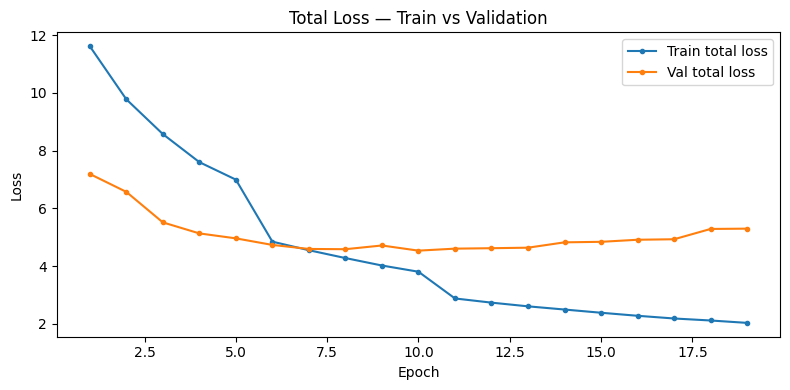

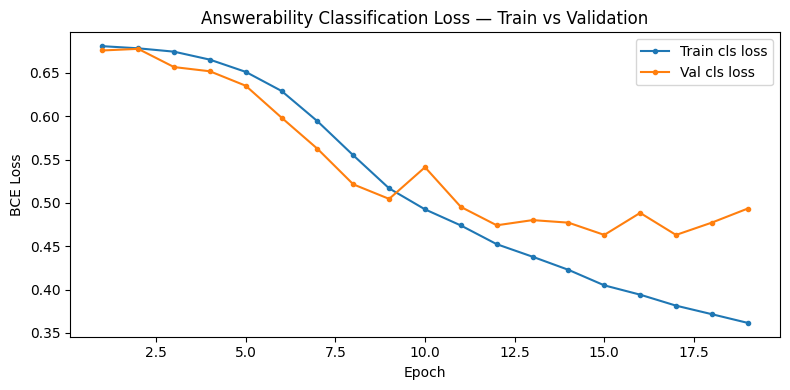

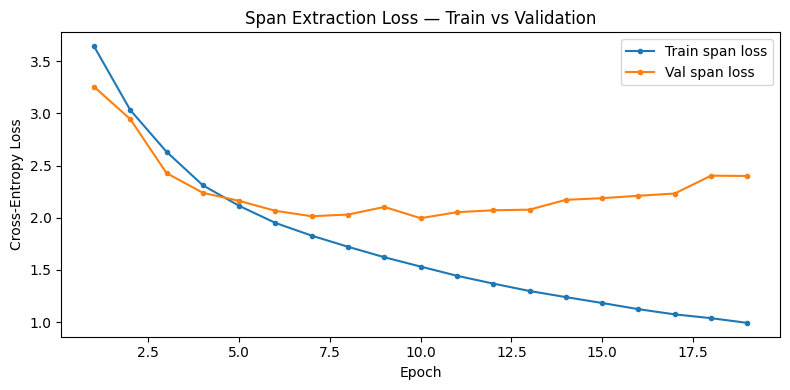

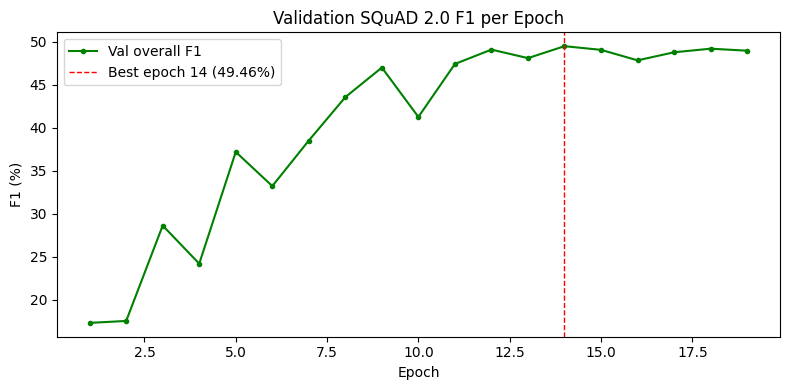

In [26]:

HIDDEN_DIM  = 100   # BiLSTM hidden units per direction (H=200 after bidirectional concat)
DROPOUT     = 0.15  # Dropout probability applied after embeddings and between layers
NUM_EPOCHS  = 25    # Maximum number of training epochs (early stopping may trigger earlier)
NUM_HIGHWAY = 2     # Number of highway network layers (paper value: 2)
BATCH_SIZE  = 32    # Examples per gradient update
PATIENCE    = 5     # Early stopping patience: stop if val F1 does not improve

RESUME = False # set it to True to resume training from the last checkpoint (if available)

CHECKPOINT_PATH = "/workspace/final_weights_BiDAF"

model = BiDAFQA(
    vocab_size      = len(word2idx),       # number of words in vocabulary
    char_vocab_size = len(char2idx),       # number of characters in vocabulary
    embed_dim       = EMBED_DIM,           # GloVe vector dimension (300)
    char_embed_dim  = CHAR_EMBED_DIM,      # character embedding dimension (64)
    char_out_dim    = CHAR_OUT_DIM,        # CNN output dimension per token (100)
    char_kernel     = CHAR_KERNEL,         # CNN filter width (5)
    hidden_dim      = HIDDEN_DIM,          # BiLSTM hidden size per direction (100)
    embeddings      = glove_emb,           # pre-trained GloVe matrix
    dropout         = DROPOUT,             # dropout probability (0.15)
    num_highway     = NUM_HIGHWAY,         # number of highway layers (2)
).to(device)   # move all parameters to GPU (or CPU if no GPU available)

optimizer = torch.optim.Adadelta(model.parameters(), rho=0.95, eps=1e-6)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')
print(f'Optimizer: Adadelta (rho=0.95, eps=1e-6)')
print(f'Early stopping patience: {PATIENCE} epochs')
print(f'Curriculum: phases at epochs 1-5 / 6-10 / 11+')

best_val_f1      = 0.0    # best overall SQuAD 2.0 F1 seen so far
best_model_state = None   # copy of the model weights at the best epoch
history          = []     # list of per-epoch metric dicts for analysis
start_epoch      = 1      # first epoch to run (changes if resuming)
no_improve       = 0      # consecutive epochs without F1 improvement

if RESUME and os.path.exists(CHECKPOINT_PATH):
    print(f'\nCheckpoint found at {CHECKPOINT_PATH} — resuming...')
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])         # restore model weights
    optimizer.load_state_dict(ckpt['optimizer_state']) # restore optimiser state
    best_val_f1      = ckpt['best_val_f1']
    best_model_state = ckpt['model_state']
    history          = ckpt['history']
    start_epoch      = ckpt['epoch'] + 1    # resume from the NEXT epoch
    no_improve       = ckpt.get('no_improve', 0)   # default 0 if not in checkpoint
    print(f'Resumed from epoch {ckpt["epoch"]}  |  best val F1 so far: {best_val_f1:.2f}%')
elif not RESUME:
    print('RESUME=False — training from scratch.')
else:
    print('No checkpoint found — training from scratch.')

for epoch in range(start_epoch, NUM_EPOCHS + 1):

    cls_w, span_w = get_loss_weights(epoch)

    print(f'\n{"="*62}')
    print(f' Epoch {epoch}/{NUM_EPOCHS}  |  '
          f'cls_w={cls_w}  span_w={span_w}  |  '
          f'no_improve={no_improve}/{PATIENCE}')
    print(f'{"="*62}')

    train_metrics = train_epoch(
        model, train_loader, optimizer, device,
        scheduler   = None,     # Adadelta needs no external scheduler
        cls_weight  = cls_w,
        span_weight = span_w
    )

    val_metrics, val_preds = evaluate_epoch(
        model, val_loader, device, answer_threshold=0.5
    )

    _, val_f1 = squad_v2_score(val_preds)

    history.append({
        'epoch':      epoch,
        'val_f1':     val_f1,
        'cls_w':      cls_w,
        'span_w':     span_w,
        'no_improve': no_improve,
        **{f'train_{k}': v for k, v in train_metrics.items()},
        **{f'val_{k}':   v for k, v in val_metrics.items()},
    })

    print(f"Train — total: {train_metrics['total_loss']:.4f} | "
          f"cls: {train_metrics['cls_loss']:.4f} | span: {train_metrics['span_loss']:.4f}")
    print(f"Val   — total: {val_metrics['total_loss']:.4f} | "
          f"cls: {val_metrics['cls_loss']:.4f} | span: {val_metrics['span_loss']:.4f}")
    print(f"Val SQuAD 2.0 F1 (thr=0.5): {val_f1:.2f}%")

    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve       = 0   # reset counter — we made progress

        torch.save({
            'epoch':           epoch,
            'model_state':     best_model_state,
            'optimizer_state': optimizer.state_dict(),  # preserves Adadelta accumulators
            'best_val_f1':     best_val_f1,
            'history':         history,
            'no_improve':      no_improve,
        }, CHECKPOINT_PATH)
        print(f'  ✓ New best model saved to Drive (val F1 = {best_val_f1:.2f}%)')

    else:
        no_improve += 1
        print(f'  No improvement for {no_improve}/{PATIENCE} epochs')

        if no_improve >= PATIENCE:
            print(f'  Early stopping triggered at epoch {epoch} '
                  f'(best val F1 = {best_val_f1:.2f}%)')
            break   # exit the training loop

    if epoch % 3 == 0:
        print_results(val_preds, split='val')

epochs_hist  = [h['epoch']            for h in history]
train_total  = [h['train_total_loss'] for h in history]
val_total    = [h['val_total_loss']   for h in history]
train_cls    = [h['train_cls_loss']   for h in history]
val_cls      = [h['val_cls_loss']     for h in history]
train_span   = [h['train_span_loss']  for h in history]
val_span     = [h['val_span_loss']    for h in history]
val_f1_curve = [h['val_f1']          for h in history]

best_epoch_plot = epochs_hist[int(np.argmax(val_f1_curve))]
best_f1_plot    = max(val_f1_curve)

plt.figure(figsize=(8, 4))
plt.plot(epochs_hist, train_total, label='Train total loss', marker='o', markersize=3)
plt.plot(epochs_hist, val_total,   label='Val total loss',   marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Total Loss — Train vs Validation')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_hist, train_cls, label='Train cls loss', marker='o', markersize=3)
plt.plot(epochs_hist, val_cls,   label='Val cls loss',   marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Answerability Classification Loss — Train vs Validation')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_hist, train_span, label='Train span loss', marker='o', markersize=3)
plt.plot(epochs_hist, val_span,   label='Val span loss',   marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Span Extraction Loss — Train vs Validation')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_hist, val_f1_curve, label='Val overall F1', marker='o', markersize=3, color='green')
plt.axvline(x=best_epoch_plot, color='red', linestyle='--', linewidth=1,
            label=f'Best epoch {best_epoch_plot} ({best_f1_plot:.2f}%)')
plt.xlabel('Epoch')
plt.ylabel('F1 (%)')
plt.title('Validation SQuAD 2.0 F1 per Epoch')
plt.legend()
plt.tight_layout()
plt.show()

#### 9.3) Final results



- **Total Loss**: train loss drops steeply from 11.58 to ~2.0 across 19 epochs, confirming consistent learning. Val loss decreases until epoch 5 (~4.5) then plateaus and slightly increases from epoch 12 onwards — the first sign of the train/val gap widening due to mild overfitting.

- **Answerability Classification Loss**:  both curves decrease steadily and remain close until epoch 6, where the curriculum phase transition (cls_w: 1.0→1.5) produces a visible spike in val cls loss before stabilising. From epoch 10 onwards train cls loss continues dropping while val cls loss plateaus around 0.47 — the classifier is overfitting slightly in later epochs.

- **Span Extraction Loss**: the clearest overfitting signal: train span loss falls continuously to ~1.0, while val span loss stops improving at ~2.0 from epoch 7 onwards and slowly increases. This confirms that span extraction is the primary bottleneck and the model is memorising training spans rather than generalising.

- **Val F1 per Epoch**: F1 grows from 17% (epoch 1) to a peak of **49.46% at epoch 14** (best checkpoint, marked by the red dashed line), then oscillates between 46–49% before early stopping triggers at epoch 19. The oscillation in later epochs reflects the tension between the decreasing span loss on training data and the plateaued val span loss.

**Best Model** results from epoch 14: `Val SQuAD 2.0 F1 (thr=0.5): 49.46%`

## 10) Threshold Tuning + Final Test Evaluation


Final three-step evaluation pipeline run on the **best model checkpoint** (`epoch 14, val F1=49.46% at thr=0.5`, not the last epoch, which may have overfit):

1. **Load best model**:  restores weights from the highest val F1 checkpoint

2. **Tune threshold on validation**: sweeps 17 thresholds (0.10–0.90), selects the one maximising SQuAD 2.0 F1. The best threshold found is **0.80**, significantly higher than the default 0.5. This happens because the model was trained on a dataset where ~58% of examples are answerable, causing it to be systematically overconfident, it outputs high answerability probabilities more often than warranted. Raising the threshold forces the model to be more certain before predicting "answerable", reducing false positives. The effect is visible in the unanswerable recall jumping from 0.70 (during training) to **0.94** after tuning, at the cost of answerable recall dropping from 0.62 to 0.54.

3. **Evaluate on val + test** with threshold=0.80:
   - **Val**: F1 improves from 49.46% → **51.32%** — the +1.86% gain is entirely from threshold tuning, with no retraining
   - **Test**: F1 = **51.01%** — minimal gap vs val (0.31%), confirming no overfitting to the validation set

**Confusion matrices** are plotted for both splits to visualise answerability errors:
- **False positives** (predicted answerable, actually unanswerable): model hallucinates an answer; reduced significantly by raising the threshold
- **False negatives** (predicted unanswerable, actually answerable):  model abstains when it should extract a span; increased slightly by the higher threshold

**Final results:**

| Split | Overall EM | Overall F1 | Cls Accuracy | Span F1 (ans. only) |
|-------|-----------|-----------|-------------|-------------------|
| Val (tuned thr=0.80) | 44.47% | 51.32% | 71.00% | 20.47% |
| Test (tuned thr=0.80) | 43.69% | 51.01% | 70.00% | 21.40% |

Span F1 (answerable only) remains at ~20–21%, confirming that **span extraction**, not answerability classification, **is the primary performance bottleneck of the BiDAF + GloVe approach**.

In [27]:
print('Loading best model...')
model.load_state_dict(best_model_state)
model.to(device)

best_threshold = tune_threshold(model, val_loader, device)

print('\n--- Validation set (tuned threshold) ---')
_, val_preds_tuned = evaluate_epoch(
    model, val_loader, device, answer_threshold=best_threshold
)
print_results(val_preds_tuned, split='val (tuned threshold)')

print('\n--- Test set (tuned threshold) ---')
_, test_preds = evaluate_epoch(
    model, test_loader, device, answer_threshold=best_threshold
)
print_results(test_preds, split='test')



Loading best model...


Best threshold: 0.80  ->  val F1 = 51.32%

--- Validation set (tuned threshold) ---


Evaluating: 100%|██████████| 279/279 [00:06<00:00, 45.61it/s]



 ANSWERABILITY CLASSIFICATION (val (tuned threshold) set)
              precision    recall  f1-score   support

unanswerable       0.60      0.94      0.73      3747
  answerable       0.92      0.54      0.68      5166

    accuracy                           0.71      8913
   macro avg       0.76      0.74      0.71      8913
weighted avg       0.79      0.71      0.70      8913

 OFFICIAL SQuAD 2.0 SCORE  (val (tuned threshold))  N=8913
  Overall EM  : 44.47%
  Overall F1  : 51.32%   <- target: >= 60%

  [Diagnostic] Span EM  (answerable only) : 8.65%
  [Diagnostic] Span F1  (answerable only) : 20.47%
  [Diagnostic] Answerable examples        : 5166/8913

--- Test set (tuned threshold) ---


Evaluating: 100%|██████████| 281/281 [00:06<00:00, 45.64it/s]



 ANSWERABILITY CLASSIFICATION (test set)
              precision    recall  f1-score   support

unanswerable       0.59      0.92      0.72      3761
  answerable       0.91      0.54      0.68      5229

    accuracy                           0.70      8990
   macro avg       0.75      0.73      0.70      8990
weighted avg       0.77      0.70      0.70      8990

 OFFICIAL SQuAD 2.0 SCORE  (test)  N=8990
  Overall EM  : 43.69%
  Overall F1  : 51.01%   <- target: >= 60%

  [Diagnostic] Span EM  (answerable only) : 8.84%
  [Diagnostic] Span F1  (answerable only) : 21.40%
  [Diagnostic] Answerable examples        : 5229/8990


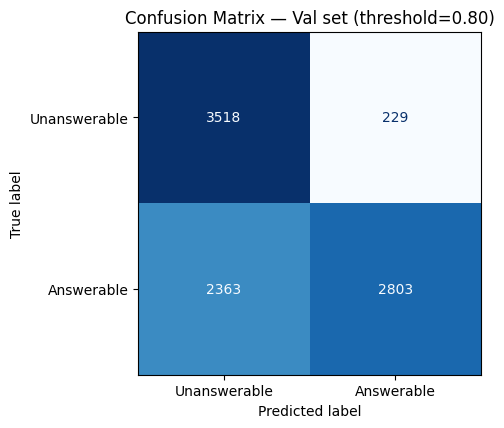

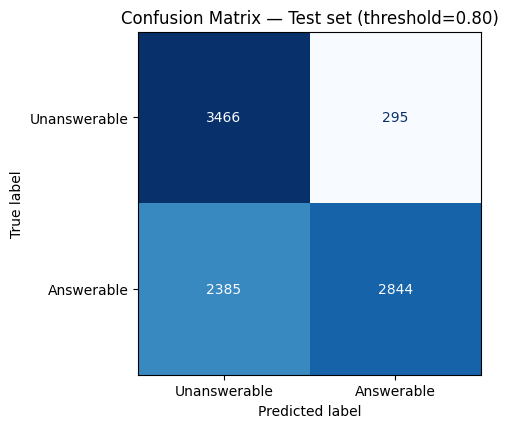

 FINAL METRICS (SUMMARY)
  Threshold usata               : 0.80
  Val  accuracy classificazione : 70.92%
  Test accuracy classificazione : 70.19%
  Val  Span F1 (answerable only): 20.47%
  Test Span F1 (answerable only): 21.40%


In [30]:

cm_val = confusion_matrix(
    val_preds_tuned['gold_answerable'],
    val_preds_tuned['pred_answerable']
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=['Unanswerable', 'Answerable']
)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Val set (threshold={best_threshold:.2f})')
plt.tight_layout()
plt.show()

cm_test = confusion_matrix(
    test_preds['gold_answerable'],
    test_preds['pred_answerable']
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=['Unanswerable', 'Answerable']
)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Test set (threshold={best_threshold:.2f})')
plt.tight_layout()
plt.show()

def cls_accuracy(preds_df):
    return (preds_df['pred_answerable'] == preds_df['gold_answerable']).mean() * 100

def diag_span_f1(preds_df):
    ans = preds_df[preds_df['gold_answerable'] == 1]
    f1s = [compute_em_f1(r.pred_text, r.gold_text)[1] for _, r in ans.iterrows()]
    return np.mean(f1s) * 100

print('=' * 50)
print(' FINAL METRICS (SUMMARY)')
print('=' * 50)
print(f'  Threshold usata               : {best_threshold:.2f}')
print(f'  Val  accuracy classificazione : {cls_accuracy(val_preds_tuned):.2f}%')
print(f'  Test accuracy classificazione : {cls_accuracy(test_preds):.2f}%')
print(f'  Val  Span F1 (answerable only): {diag_span_f1(val_preds_tuned):.2f}%')
print(f'  Test Span F1 (answerable only): {diag_span_f1(test_preds):.2f}%')
print('=' * 50)

#### 10.1) Final results



Best threshold found: **0.80**, significantly higher than the default 0.5, confirming the model is systematically overconfident (see Section 7 for the full rationale).

**Confusion Matrices:**

| | Val | Test |
|---|---|---|
| True Unanswerable → predicted Unanswerable (TN) | 3518 | 3466 |
| True Unanswerable → predicted Answerable (FP) | 229 | 295 |
| True Answerable → predicted Unanswerable (FN) | 2363 | 2385 |
| True Answerable → predicted Answerable (TP) | 2803 | 2844 |

The model is **conservative**: it correctly abstains on 3518/3747 unanswerable questions (recall=0.94) but misses 2363/5166 answerable questions (recall=0.54): it prefers to abstain rather than risk a wrong answer. This asymmetry is a direct consequence of threshold=0.80: raising it reduces false positives at the cost of increasing false negatives.

**Final summary:**

| Split | Overall EM | Overall F1 | Cls Accuracy | Span F1 (ans. only) |
|-------|-----------|-----------|-------------|-------------------|
| Val (thr=0.80) | 44.47% | 51.32% | 70.92% | 20.47% |
| Test (thr=0.80) | 43.69% | 51.01% | 70.19% | 21.40% |

**Val/Test gap is minimal** (0.31% F1, 0.73% accuracy), no overfitting to the validation set.

**Span F1 (answerable only) = 20–21%** remains the primary bottleneck. Even on examples the classifier correctly identifies as answerable, the model struggles to precisely localise the answer span: a fundamental limitation of GloVe + BiLSTM compared to contextual transformer embeddings where every token representation is informed by the full context.

## 11) Model in action


 `answer_question_bidaf` wraps the full inference pipeline into a single function: tokenisation → encoding → forward pass → answerability check → span decoding. It uses the tuned `best_threshold=0.80` by default.

The four examples below test the model on four distinct cases using a short passage about the Eiffel Tower:

- **Answerable — direct fact** (`"How tall is the Eiffel Tower?"`): the answer is explicitly stated in the passage

- **Unanswerable — fact not in context** (`"Who is the president of France?"`): the passage talks about France but contains no information about its president

- **Answerable — named entity** (`"Who designed the Eiffel Tower?"`): requires identifying a named entity mentioned in the passage

- **Unanswerable — fact never mentioned** (`"When was the Eiffel Tower painted red?"`): the passage never mentions the tower being painted red; the model should abstain

To run on custom input, replace `context` and `question` with any text of your choice. The context is truncated to `MAX_CONTEXT=300` tokens if longer.

In [31]:
def answer_question_bidaf(question, context, model, word2idx, char2idx, device,
                           answer_threshold=0.50, max_answer_len=15):
    """
    Args:
        question:         raw question string
        context:          raw context string
        answer_threshold: sigmoid threshold for answerability (default: 0.5; pass best_threshold for optimal results)
    Returns:
        answer string, or 'The model cannot answer this question.' if unanswerable
    """
    model.eval()
    
    ctx_tokens = tokenize(context)[:MAX_CONTEXT]
    q_tokens   = tokenize(question)[:MAX_QUESTION]

    ctx_ids,   ctx_mask  = encode_sequence(ctx_tokens, word2idx, MAX_CONTEXT)
    q_ids,     q_mask    = encode_sequence(q_tokens,   word2idx, MAX_QUESTION)
    ctx_chars            = tokens_to_char_ids(ctx_tokens, char2idx, MAX_CONTEXT)
    q_chars              = tokens_to_char_ids(q_tokens,   char2idx, MAX_QUESTION)
    ctx_em               = exact_match_feature(ctx_tokens, q_tokens, MAX_CONTEXT)

    def to_tensor(x, dtype):
        return torch.tensor(x, dtype=dtype).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(
            to_tensor(ctx_ids,   torch.long),
            to_tensor(ctx_mask,  torch.float),
            to_tensor(ctx_chars, torch.long),
            to_tensor(ctx_em,    torch.float),
            to_tensor(q_ids,     torch.long),
            to_tensor(q_mask,    torch.float),
            to_tensor(q_chars,   torch.long),
        )

    prob = torch.sigmoid(outputs['answerable_logits']).item()
    if prob < answer_threshold:
        return 'The model cannot answer this question.'

    s, e = best_span_from_logits(
        outputs['start_logits'][0].cpu(),
        outputs['end_logits'][0].cpu(),
        max_answer_len=max_answer_len
    )
    return span_to_text(ctx_tokens, s, e)


# ── Examples ──────────────────────────────────────────────────────────────────
context = """
The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.
It is named after the engineer Gustave Eiffel, whose company designed and built the tower
from 1887 to 1889. The tower is 330 metres tall and was the tallest man-made structure in
the world for 41 years.
"""

# Question with answer
question1 = "How tall is the Eiffel Tower?"
answer1   = answer_question_bidaf(question1, context, model, word2idx, char2idx, device, answer_threshold=best_threshold)
print(f"Q: {question1}")
print(f"A: {answer1}\n")

# Question without answer in context
question2 = "Who is the president of France?"
answer2   = answer_question_bidaf(question2, context, model, word2idx, char2idx, device, answer_threshold=best_threshold)
print(f"Q: {question2}")
print(f"A: {answer2}\n")

# Question about a fact present in the context
question3 = "Who designed the Eiffel Tower?"
answer3   = answer_question_bidaf(question3, context, model, word2idx, char2idx, device, answer_threshold=best_threshold)
print(f"Q: {question3}")
print(f"A: {answer3}\n")

# Question about a fact not present in the context
question4 = "When was the Eiffel Tower painted red?"
answer4   = answer_question_bidaf(question4, context, model, word2idx, char2idx, device, answer_threshold=best_threshold)
print(f"Q: {question4}")
print(f"A: {answer4}\n")

Q: How tall is the Eiffel Tower?
A: is 330 metres

Q: Who is the president of France?
A: The model cannot answer this question.

Q: Who designed the Eiffel Tower?
A: engineer gustave eiffel

Q: When was the Eiffel Tower painted red?
A: The model cannot answer this question.



## 12) Conclusions



The BiDAF model with GloVe embeddings, character-level CNN, exact-match features, and self-attention achieves **51.01% F1 and 43.69% EM on the test set**: a discrete baseline for a non-transformer QA system trained from scratch on a sampled version of SQuAD 2.0.

### 12.1) Possible limitations



- **Static word representations (GloVe):** GloVe assigns a single fixed vector to each word regardless of context. The word "bank" receives the same vector whether it refers to a financial institution or a river bank. This is a fundamental limitation for QA, where understanding the correct sense of a word in context is critical for localising the answer span. Transformer-based models like DeBERTa produce contextualised representations where every token's embedding depends on the full surrounding sequence: this is the single largest architectural advantage they have over GloVe-based systems.

- **No document-level context (re-centering vs doc_stride):** BiDAF processes a fixed window of 300 tokens centred around the answer. For long passages where relevant evidence is spread across multiple paragraphs, the model only sees a fraction of the context. DeBERTa's sliding window with `doc_stride=128` processes the full document in overlapping chunks, allowing it to consider evidence from any position in the passage.

- **Span extraction bottleneck:** Diagnostic Span F1 of ~21% (answerable only) reveals that even when the model correctly identifies a question as answerable, it struggles to precisely delimit the answer boundaries. This is partly a consequence of GloVe's static representations and partly a limitation of the BiLSTM encoder, which has a fixed hidden size of H=200 and cannot capture the deep contextual interactions that transformer attention heads provide.

- **Answerability classifier conservatism:** With the tuned threshold of 0.80, the model misses ~46% of answerable questions (recall=0.54). This conservative behaviour is a side effect of the class imbalance in the training set and the miscalibration of raw sigmoid outputs, a known weakness of BCE-trained classifiers without explicit calibration.

- **Training data size:** The model was trained on a sampled subset of SQuAD 2.0 (~71k examples vs the full ~130k). Larger training data would likely improve both span extraction and answerability calibration.

### 12.2) Why Transformers Would Help



The comparison with the DeBERTa-based model in this project directly illustrates the gap between classical and modern QA approaches. Transformer architectures address all of the above limitations simultaneously:

- **Contextualised embeddings**: every token representation is informed by every other token via multi-head self-attention, resolving ambiguity and coreference natively

- **Pre-training on large corpora**: DeBERTa was pre-trained on billions of tokens, giving it linguistic knowledge that BiDAF must learn entirely from the 52k SQuAD examples

- **Doc stride support**: native offset mapping enables full-document processing without information loss

- **Disentangled attention**: DeBERTa's disentangled attention mechanism separately models content and position, improving span boundary detection

BiDAF remains relevant as a lightweight, interpretable baseline that can run efficiently without a GPU and requires no pre-trained transformer weights. For production QA systems where latency and compute cost matter, a well-tuned BiDAF-style model is still a viable option. 

## 13) References


**Model Architecture**
- Seo, M., Kembhavi, A., Farhadi, A., & Hajishirzi, H. (2016). *Bidirectional Attention Flow for Machine Comprehension*. ICLR 2017. [[paper]](https://arxiv.org/abs/1611.01603)

**Word Embeddings**
- Pennington, J., Socher, R., & Manning, C. (2014). *GloVe: Global Vectors for Word Representation*. EMNLP 2014. [[paper]](https://nlp.stanford.edu/pubs/glove.pdf) [[vectors]](https://nlp.stanford.edu/projects/glove/)

**Optimiser**
- Zeiler, M. D. (2012). *ADADELTA: An Adaptive Learning Rate Method*. [[paper]](https://arxiv.org/abs/1212.5701)

**Self-Attention**
- Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). *Attention Is All You Need*. NeurIPS 2017. [[paper]](https://arxiv.org/abs/1706.03762)
